# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [43]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [44]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [45]:
# mostrar las primeras 5 filas de plans
plans.head()
# print(plans.shape)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [46]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [47]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [48]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [49]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [50]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [51]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [52]:
# cantidad de nulos para users
print(plans.isna().sum())
print()
print(plans.isna().mean())

plan_name            0
messages_included    0
gb_per_month         0
minutes_included     0
usd_monthly_pay      0
usd_per_gb           0
usd_per_message      0
usd_per_minute       0
dtype: int64

plan_name            0.0
messages_included    0.0
gb_per_month         0.0
minutes_included     0.0
usd_monthly_pay      0.0
usd_per_gb           0.0
usd_per_message      0.0
usd_per_minute       0.0
dtype: float64


In [53]:
# cantidad de nulos para usage
print(usage.isna().sum())
print()
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.
Para el dataframe plans no hay valores nulos, pero para el caso de usage (duration y length) tienen un 50% de datos nulos, no seria viable eliminar los datos.
💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---
**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  Para el caso de usage (duration y length) 
- Indica qué harías: ¿imputar, eliminar, ignorar? Propongo rellenar con la mediana los datos faltantes

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [54]:
# explorar columnas numéricas de users
users[['user_id', 'age']].describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` El identificador de usuarios no tiene informacion relevante, ya que solo es un identificador.
- La columna `age` Tiene edades invalidas o nulas y negativa que es -999.

In [55]:
# explorar columnas numéricas de usage
usage[['id', 'user_id','duration','length']].describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id`Para id se comienza desde (1 hasta 40000) y para el caso de user_id (tiene un dato faltante)
- Las columnas  duration y length muestran el conteo de los valores no nulos.

In [56]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
for col in columnas_user:
    print()
    print(col)
    print()
    print(users[col].unique())



city

['Medellín' '?' 'CDMX' 'Bogotá' 'GDL' 'MTY' nan 'Cali']

plan

['Basico' 'Premium']


- La columna `city` Tiene datos invalidos como "?" y "nan"
- La columna `plan` tiene unicamente dos valores pero son balidos, "Basico y Premium"

In [57]:
# explorar columna categórica de usage
usage['type'].unique()

array(['call', 'text'], dtype=object)

- La columna `type` contiene solo 2 categorias unicas "call y text"


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 
En city, hay valores nulos como "NaN y  ?" Unicamente es necesario sustituir los valores nulos "?" a un nulo valido como NaN
**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?  

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [58]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'],errors='coerce')

In [59]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'])

In [60]:
# Revisar los años presentes en `reg_date` de users
print(users['reg_date'].dt.year.unique())

[2022 2026 2023 2024]


En `reg_date`, se observan que los años van desde 2022 hasta 2026 pero sin estan presente el año 2025

In [61]:
# Revisar los años presentes en `date` de usage
print(usage['date'].dt.year.unique())

[2024.   nan]


En `date`, se encuentran registros con el año 2024 y años invalidos como "nan"
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:
En user los años que se manejan no tienen problemas, siempre y cuando descartemos que 2025 no debe estar presente y para usage solo se maneja 1 año que es 2024
**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas? para usage se dberian dejar los valores como nan y para users es necesario validar que 2025 no es una fecha que deba aparecer.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [62]:
# Reemplazar -999 por la mediana de age
users['age'] = users['age'].replace(-999, pd.NA)
age_mediana = users['age'].median()
users['age'] = users['age'].fillna(age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [63]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)
# Verificar cambios
users['city'].unique()

array(['Medellín', <NA>, 'CDMX', 'Bogotá', 'GDL', 'MTY', nan, 'Cali'],
      dtype=object)

In [64]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'] > pd.Timestamp.today(), 'reg_date'] = pd.NaT
# Verificar cambios
users[users['reg_date'] > pd.Timestamp.today()]

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [65]:
# Verificación MAR en usage (Missing At Random) para duration
usage[['duration','type']].head(1000)


,duration,type
0,0.09,call
1,NaN,text
2,NaN,text
3,1.53,call
4,4.84,call
...,...,...
995,NaN,text
996,0.39,call
997,4.40,call
998,3.80,call


In [66]:
# Verificación MAR en usage (Missing At Random) para length
usage[['length','type']].head(60)

,length,type
0,NaN,call
1,39.0,text
2,36.0,text
3,NaN,call
4,NaN,call
5,NaN,call
6,NaN,call
7,NaN,call
8,44.0,text
9,70.0,text


 Nulos en `duration` y `length` Encontre un patrón, para duration y type (text=NAN) y para lenght y type (call=NAN) no son nulos aleatorios,los conservo como nulos

---

## 🧩Paso 4: Summary statistics de uso por usuario

### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [67]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas
# Agrupar información por usuario
usage_agg = usage.groupby("user_id")[["is_text","is_call","duration"]].sum().reset_index()
# observar resultado
usage_agg.head()

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74
3,10003,11,3,8.99
4,10004,4,3,8.01


In [68]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={ "is_text": "cant_mensajes","is_call": "cant_llamadas","duration":"cant_minutos_llamada"})
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [69]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = usage_agg.merge(users, on="user_id")
user_profile.head(5)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,7,3,23.70,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,5,10,33.18,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,5,2,10.74,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,11,3,8.99,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,4,3,8.01,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [70]:
# Resumen estadístico de las columnas numéricas
user_profile[["cant_mensajes","cant_llamadas","cant_minutos_llamada","age"]].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada,age
count,3999.000000,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054,48.138285
std,2.358416,2.144238,18.168095,17.691541
min,0.000000,0.000000,0.000000,18.000000
25%,4.000000,3.000000,11.120000,33.000000
50%,5.000000,4.000000,19.780000,48.000000
75%,7.000000,6.000000,31.415000,63.000000
max,17.000000,15.000000,155.690000,79.000000


In [71]:
# Distribución porcentual del tipo de plan
user_profile["plan"].value_counts(normalize=True)*100
#user_profile["cant_minutos_llamada"].value_counts().head(10)

Basico     64.866217
Premium    35.133783
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

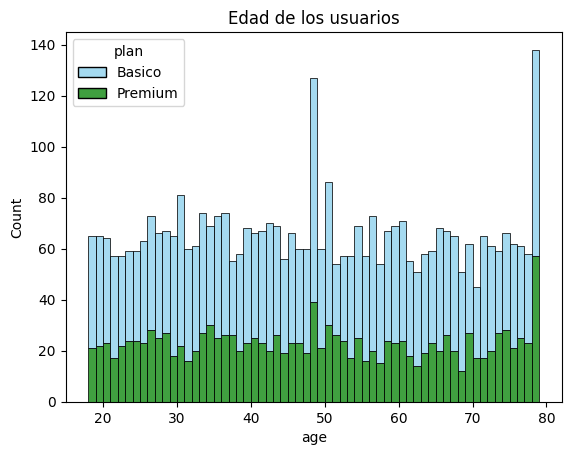

In [72]:
# Histograma para visualizar la edad (age)
sns.histplot( data=user_profile, x="age", hue="plan", binwidth=1, multiple="stack", palette=["skyblue", "green"] )
plt.title("Edad de los usuarios")
plt.show()

💡Insights:Para el plan Premium y Basico la edad de 48, 50 y 79 son las más frecuentes, y tanto para basico como para premium los usuarios más frecuentes tienen una edad de 78 a 79 años, por lo que deberiamos enfocarnos en atraer más publico para edades más bajas o retener usuarios con las edades mas frecuentes.
- Distribución ... No tiene una distribucion especifica

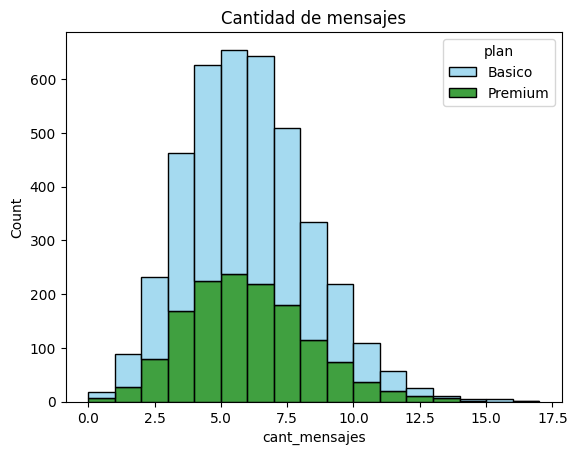

In [73]:
# Histograma para visualizar la cant_mensajes
sns.histplot( data=user_profile, x="cant_mensajes", hue="plan", binwidth=1, multiple="stack", palette=["skyblue", "green"] )
plt.title("Cantidad de mensajes")
plt.show()

💡Insights: Se observa que el promedio de mensajes o texto esta entre 5 para usarios tanto premium como basico, aunque el paquete basico es el que registra mayor número de usuarios para mensajes.
- Distribución: tiene un sesgo a la derecha para datos un poco fuera de la media, como es el caso de 17.

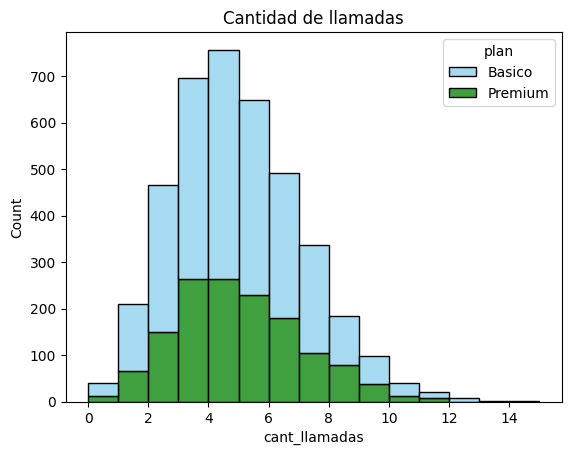

In [74]:
# Histograma para visualizar la cant_llamadas
sns.histplot( data=user_profile, x="cant_llamadas", hue="plan", binwidth=1, multiple="stack", palette=["skyblue", "green"] )
plt.title("Cantidad de llamadas")
plt.show()


💡Insights: Los datos se agrupan en su mayoria cerca del promedio para ambos planes, el paquete basico y premium el mayor número de llamadas registradas es entre 3 y 5
- Distribución: tiene un sesgo a la derecha para datos un poco fuera de la media, como es el caso de 14 y 15 en llamadas.

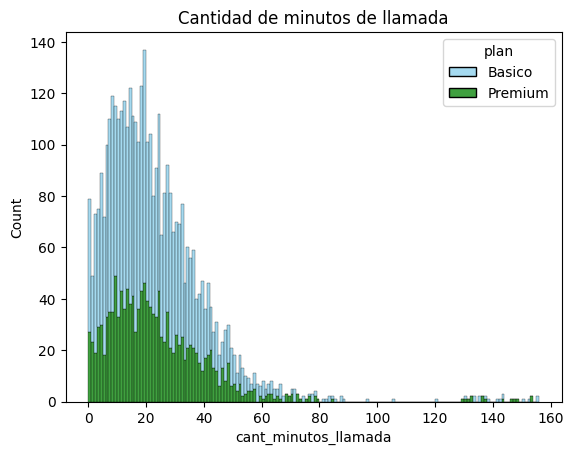

In [75]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot( data=user_profile, x="cant_minutos_llamada", hue="plan", binwidth=1, multiple="stack", palette=["skyblue", "green"] )
plt.title("Cantidad de minutos de llamada")
plt.show()

💡Insights: para el paquete premium 9,11, 13 y 20 minutos,son los más frecuentes en llamadas y para que plan basico 13, 17, 18 y 20 son los minutos más frecuentes para llamadas
- Distribución: tiene un sesgo a la derecha para datos muy fuera de la media que van desde 130 a 150

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>
- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

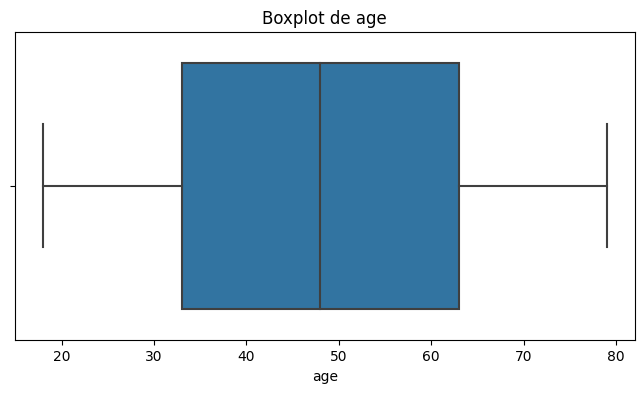

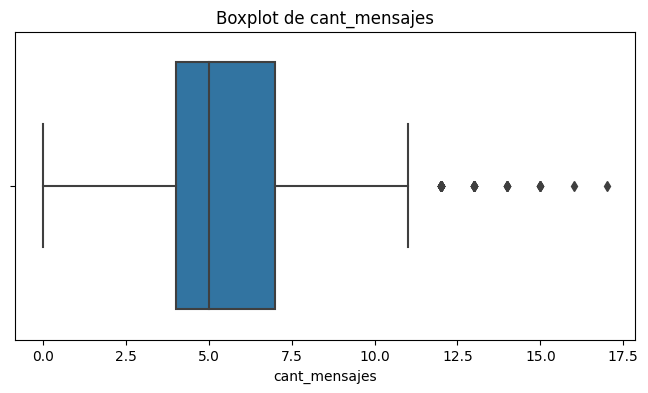

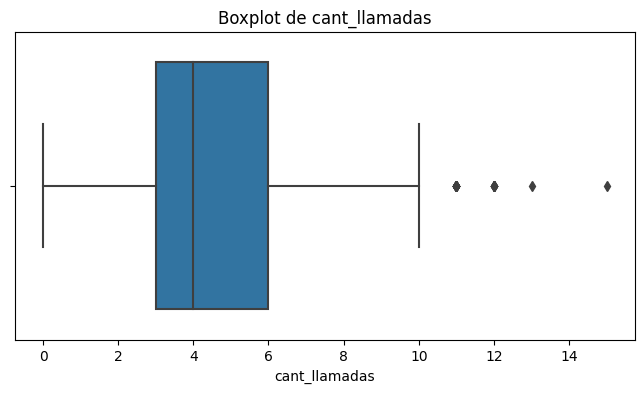

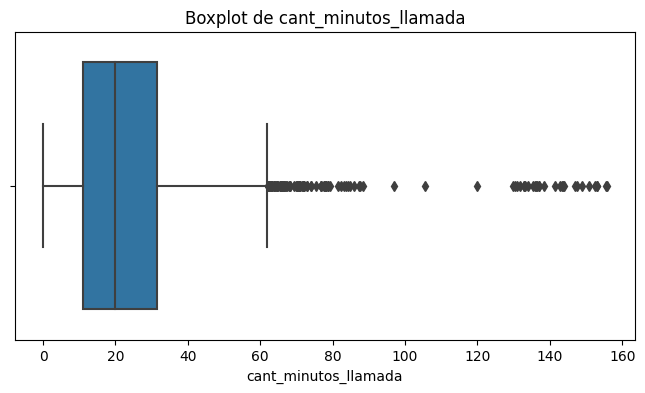

In [76]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=user_profile[col])
    plt.title(f'Boxplot de {col}')
    plt.show()



💡Insights: 
- Age: ... tiene una distribución asimetrica y no presenta outliers
- cant_mensajes: ... tiene una distribución con sesgo a la derecha y presenta outliers por encima de 12
- cant_llamadas: ... tiene una distribución con sesgo a la derecha y presenta outliers por encima de 10
- cant_minutos_llamada: ... tiene una distribución con sesgo a la derecha y presenta outliers por encima de 60

In [77]:
# Calcular límites con el método IQR
columnas_limites = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)

    IQR = Q3-Q1
    
    Upper = Q3 + 1.5* IQR

    print(f"\nColumna: {col}")
    print(f"Q1: {Q1}")
    print(f"Q3: {Q3}")
    print(f"IQR: {IQR}")
    print(f"Límite superior: {Upper}")
    



Columna: age
Q1: 33.0
Q3: 63.0
IQR: 30.0
Límite superior: 108.0

Columna: cant_mensajes
Q1: 4.0
Q3: 7.0
IQR: 3.0
Límite superior: 11.5

Columna: cant_llamadas
Q1: 3.0
Q3: 6.0
IQR: 3.0
Límite superior: 10.5

Columna: cant_minutos_llamada
Q1: 11.12
Q3: 31.415
IQR: 20.295
Límite superior: 61.8575


In [78]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000,3999.000000
mean,48.138285,5.524381,4.478120,23.317054
std,17.691541,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: mantener o no outliers, porqué? Aunque el limite superior es 11.5 mensajes y en describe() tenemos un max de 17, no lo considero outlier ya que 17 es un número posible de mensajes " Mantengo los datos atipicos"
- cant_llamadas: mantener o no outliers, porqué? Aunque el limite superior es 10.5 llamadas y en describe() tenemos un max de 15, no lo considero outlier ya que 15 es un número posible de llamadas " Mantengo los datos atipicos"
- cant_minutos_llamada: mantener o no outliers, porqué? Aunque el limite superior es 61.85 min_llamada y en describe() tenemos un max de 155, no lo considero outlier ya que 155 min_llamada es un número posible de minutos en llamada " Mantengo los datos atipicos"

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [79]:
# Crear columna grupo_uso
#grupo_uso = df

columnas_for = ["cant_mensajes", "cant_llamadas"]
def clasificacion(columna):
    if all(columna[col] < 5 for col in columnas_for):
        return "Bajo uso"
    elif all(columna[col] < 10 for col in columnas_for):
        return "Uso medio"
    else:
        return "Alto uso"

user_profile["grupo_uso"] = user_profile.apply(clasificacion, axis=1)



In [80]:
# verificar cambios
user_profile.head()

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date,grupo_uso
0,10000,7,3,23.70,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,Uso medio
1,10001,5,10,33.18,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,Alto uso
2,10002,5,2,10.74,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,Uso medio
3,10003,11,3,8.99,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,Alto uso
4,10004,4,3,8.01,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [81]:
# Crear columna grupo_edad
columnas_for2= ["age"]
def edad(años):
    if all(años[col]<30 for col in columnas_for2):
        return "Joven"
    elif all(años[col]<60 for col in columnas_for2):
        return "Adulto"
    else:
       return "Adulto Mayor"
user_profile["grupo_edad"]=user_profile.apply(edad, axis=1)

In [82]:
# verificar cambios
user_profile.head()

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date,grupo_uso,grupo_edad
0,10000,7,3,23.70,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,Uso medio,Adulto
1,10001,5,10,33.18,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,Alto uso,Adulto
2,10002,5,2,10.74,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,Uso medio,Adulto
3,10003,11,3,8.99,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,Alto uso,Adulto Mayor
4,10004,4,3,8.01,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

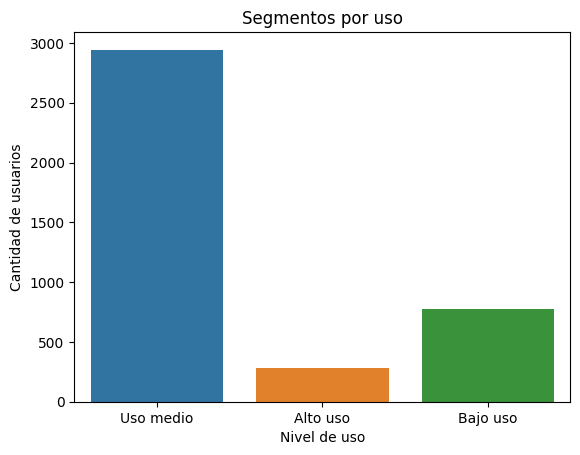

In [83]:
# Visualización de los segmentos por uso
sns.countplot(x="grupo_uso", data=user_profile)
plt.title("Segmentos por uso")
plt.xlabel("Nivel de uso")
plt.ylabel("Cantidad de usuarios")
plt.show()

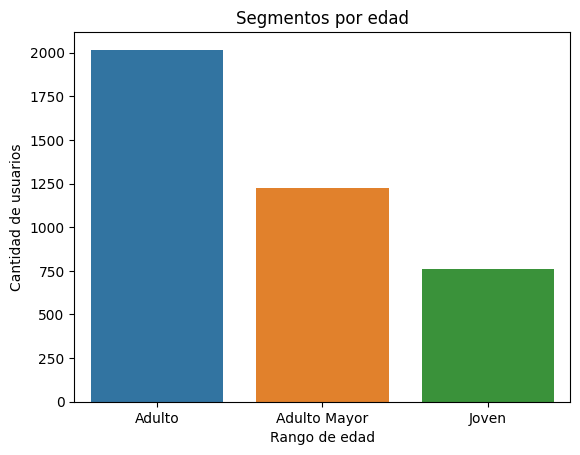

In [84]:
# Visualización de los segmentos por edad
sns.countplot(x="grupo_edad", data=user_profile)
plt.title("Segmentos por edad")
plt.xlabel("Rango de edad")
plt.ylabel("Cantidad de usuarios")
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?
Algunos datos nulos como el caso de "?" y -999 o valores negativos "-"

- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?
En los tres segmentos de uso los jovenes son lo que menos frecuencia en llamadas y mensajes presentan, a diferencia de los adultos, y el alto uso de mensajes y llamadas en jovenes es el de menos interes y frecuncia.
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?
Los segmenetos de edad y uso combinado x="grupo_uso", hue="grupo_edad", ya que con esto logramos ver en que edad debemos enfocar nuestra estrategia de atracción, que es el caso de los jovenes y como retener a los adultos para que sigan consumiendo el prdocuto.
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?
No se encontraron outliers que requieran de una observación especial, ya que pueden ser valores extremos validos como es el caso de minutos de llamada que se extiende hasta 155 minutos, aproximado a 2 hrs que es algo que es muy posible que realice una persona en una llamada.
- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?
el plan basico es el que mayor número de usuarios registra, pero podriamos incentivar a que usuarios adultos se cambien a planes premium y que jovenes se mantengan o muden de premium a basico y asi aumentar el numero de usuarios en cada plan.
✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Nulos NA
- Valores invalidos -999, "?" y valores negativos en edad "-"

🔍 **Segmentos por Edad**
- Adulto
- Adulto mayor
- Joven

📊 **Segmentos por Nivel de Uso**
- Bajo
- Medio
- Alto

➡️ Esto sugiere que ...
💡 **Recomendaciones**
- Incentivar a que usuarios adultos se cambien a planes premium
- Que jovenes se mantengan o muden de premium a basico y con ello, aumentar el número de usuarios en cada plan.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`